In [1]:
## Load the glacier template and set output paths ##

from pathlib import Path
import pandas as pd
import geopandas as gpd
import json
import numpy as np
from scipy import ndimage as ndi

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from rasterio.features import rasterize, shapes
from rasterio.transform import from_origin
from shapely.geometry import shape as shapely_shape
from shapely import union_all


project_dir = Path.cwd()
input_dir = project_dir / "Input_Data"
processed_dir = project_dir / "Output_Data" / "processed"

final_dir = processed_dir / "glacier_outlines_final"
split_dir = processed_dir / "glacier_outlines_by_glacier"
split_dir.mkdir(parents = True, exist_ok = True)

glacier_path = input_dir / "heard_island_shp" / "Glacier_2014.shp"
focus_names = ["brown", "stephenson"]

# Use the inventory polygons as fixed glacier-ID boundaries.
glacier_template = gpd.read_file(glacier_path).to_crs("EPSG:32743")

required_fields = ["RGIId", "name_1", "geometry"]
missing_fields = [
    field for field in required_fields
    if field not in glacier_template.columns]

if missing_fields:
    raise ValueError(f"Missing inventory fields: {missing_fields}")

glacier_template = glacier_template[required_fields].copy()

if glacier_template["RGIId"].isna().any():
    raise ValueError("The glacier template contains missing glacier IDs.")

glacier_template["geometry"] = glacier_template.geometry.make_valid()

# Combine any separate inventory features belonging to the same glacier.
glacier_template = glacier_template.dissolve(
    by = "RGIId", as_index = False)

# Overlapping template areas would be counted against multiple glaciers.
template_footprint = glacier_template.geometry.union_all()
overlap_area = (
    glacier_template.geometry.area.sum() - template_footprint.area)

# Allow subpixel slivers while flagging larger inventory overlaps.
overlap_tolerance_m2 = 100.0

if overlap_area > overlap_tolerance_m2:
    raise ValueError(
        f"The glacier template overlaps by {overlap_area:.2f} m². "
        "Resolve those overlaps before calculating glacier areas.")

print(f"Template overlap: {overlap_area:.2f} m²")

print(f"Loaded {len(glacier_template)} glacier IDs.")

Template overlap: 4.67 m²
Loaded 23 glacier IDs.


In [2]:
## Crop individual glaciers to the accepted 2019 and 2026 outlines ##

glaciers_by_year = {}

for year in (2019, 2026):
    # Read the frozen outputs independently of the preparation notebook.
    ice = gpd.read_file(
        final_dir / f"Heard_ice_{year}_final.gpkg",
        layer = f"ice_{year}").to_crs(glacier_template.crs)

    if ice.empty:
        raise ValueError(f"{year}: the accepted ice footprint is empty.")

    ice_footprint = ice.geometry.union_all()

    # Retain inventory attributes while replacing each glacier's extent.
    split = gpd.clip(
        glacier_template, ice_footprint,
        keep_geom_type = True).reset_index(drop = True)

    # Check that the split reconstructs the complete accepted footprint.
    split_footprint = split.geometry.union_all()
    coverage_error = ice_footprint.symmetric_difference(
        split_footprint).area

    if coverage_error > 1.0:
        raise ValueError(
            f"{year}: {coverage_error:.2f} m² differs between the "
            "accepted footprint and the glacier split. Check the template.")

    split["year"] = year
    split["area_km2"] = split.geometry.area / 1_000_000

    # Other glaciers retain their known mapping limitations.
    study_glacier = (
        split["name_1"].astype("string")
        .str.strip().str.casefold().isin(focus_names))

    split["scope"] = study_glacier.map({
        True: "study",
        False: "context"})

    split.to_file(
        split_dir / f"Heard_glaciers_{year}.gpkg",
        layer = f"glaciers_{year}", driver = "GPKG", index = False)

    split.to_file(
        split_dir / f"Heard_glaciers_{year}.shp",
        driver = "ESRI Shapefile", index = False)

    glaciers_by_year[year] = split

    print(
        f"{year}: saved {len(split)} glacier features; "
        f"footprint difference = {coverage_error:.3f} m².")

2019: saved 21 glacier features; footprint difference = 0.000 m².
2026: saved 21 glacier features; footprint difference = 0.000 m².


In [3]:
## Summarise the mapped areas of Brown and Stephenson ##

area_summary = glacier_template[["RGIId", "name_1"]].copy()
area_summary["area_2014_km2"] = (
    glacier_template.geometry.area / 1_000_000)

for year, glaciers in glaciers_by_year.items():
    areas = glaciers.set_index("RGIId")["area_km2"]

    # Glaciers with no remaining mapped polygon receive zero mapped area.
    area_summary[f"area_{year}_km2"] = (
        area_summary["RGIId"].map(areas).fillna(0))

study_glacier = (
    area_summary["name_1"].astype("string")
    .str.strip().str.casefold().isin(focus_names))

focus_area_summary = area_summary.loc[study_glacier].copy()

focus_area_summary.to_csv(
    split_dir / "Brown_Stephenson_mapped_areas.csv", index = False)

display(focus_area_summary.round(3))

,RGIId,name_1,area_2014_km2,area_2019_km2,area_2026_km2
4,RGI60-19.00005,Stephenson,9.227,8.376,8.143
22,RGI60-19.00023,Brown,3.404,3.333,3.191


In [4]:
## Inspect the historical glacier inventory files ##

inventory_dir = input_dir / "heard_island_shp"

for path in sorted(inventory_dir.glob("*.shp")):
    frame = gpd.read_file(path)
    attributes = frame.drop(columns = frame.geometry.name)

    print(f"\n{path.name}")
    print(f"Features: {len(frame)} | CRS: {frame.crs}")
    print("Fields:", attributes.columns.tolist())

    # Show all recorded years or dates where those fields are identifiable.
    for column in attributes.columns:
        if any(term in column.lower() for term in ["year", "date"]):
            print(
                f"{column}:",
                attributes[column].dropna().unique().tolist())

    display(attributes.head(3))


Contours_4326.shp
Features: 238 | CRS: EPSG:4326
Fields: ['FEAT_TYPE', 'ELEVATION', 'CERTAINTY', 'RELIEF', 'SURFACE', 'DATASET_ID', 'METADATAID', 'DQI', 'ADDCODE', 'index', 'label']


,FEAT_TYPE,ELEVATION,CERTAINTY,RELIEF,SURFACE,DATASET_ID,METADATAID,DQI,ADDCODE,index,label
0,CONTOUR_LINE,500.0,definite,standard,unknown,1,gis1,0,0,1.0,500.0
1,CONTOUR_LINE,500.0,definite,standard,unknown,1,gis1,0,0,1.0,500.0
2,CONTOUR_LINE,500.0,definite,standard,unknown,1,gis1,0,0,1.0,500.0



Glacier_2014.shp
Features: 23 | CRS: EPSG:4326
Fields: ['RGIId', 'CenLon', 'CenLat', 'GLIMSId', 'BgnDate', 'EndDate', 'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope', 'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging', 'Linkages', 'check_geom', 'Name', 'name_1']
BgnDate: ['20009999']
EndDate: ['9999999']


,RGIId,CenLon,CenLat,GLIMSId,BgnDate,EndDate,O1Region,O2Region,Area,Zmin,...,Lmax,Status,Connect,Form,TermType,Surging,Linkages,check_geom,Name,name_1
0,RGI60-19.00001,73.494885,-53.045487,None,20009999,9999999,19,01,-9999.0,-9999.0,...,-9999,0,0,0,0,0,1,None,None,AU1041
1,RGI60-19.00002,73.440651,-53.107616,None,20009999,9999999,19,01,-9999.0,-9999.0,...,-9999,0,0,0,0,0,1,None,None,Abbotsmith
2,RGI60-19.00003,73.515403,-53.133039,None,20009999,9999999,19,01,-9999.0,-9999.0,...,-9999,0,0,0,0,0,1,None,None,Gotley



Glacier_outlines_1947_2014.shp
Features: 299 | CRS: EPSG:4326
Fields: ['feat_type', 'type', 'name', 'descriptio', 'source', 'certainty', 'status', 'display', 'date_captu', 'date_flag', 'db_date_cr', 'metadata_i', 'feature_so', 'attribute_', 'att_reliab', 'spatial_me', 'spat_relia', 'planimetri', 'elevation_', 'aadc_comme', 'st_area_sh', 'st_perimet']
date_captu: [Timestamp('2008-03-23 00:00:00'), Timestamp('2014-02-06 00:00:00'), Timestamp('2003-01-17 00:00:00'), Timestamp('1980-01-01 00:00:00'), Timestamp('2006-03-30 00:00:00'), Timestamp('1947-01-01 00:00:00'), Timestamp('1988-01-01 00:00:00'), Timestamp('1997-01-01 00:00:00'), Timestamp('2009-02-28 00:00:00')]
date_flag: ['Definite day, month and year', 'Definite year', 'Pre year']
db_date_cr: [Timestamp('2024-05-14 00:00:00')]


,feat_type,type,name,descriptio,source,certainty,status,display,date_captu,date_flag,...,feature_so,attribute_,att_reliab,spatial_me,spat_relia,planimetri,elevation_,aadc_comme,st_area_sh,st_perimet
0,Glacier,NaN,None,Ice/snow,None,None,Unknown,None,2008-03-23,"Definite day, month and year",...,"Mosaic of WorldView-1, id 1958 and 1960, both ...",WorldView-1 23 March 2008,2008-03-23,Digitising of WorldView-1 image. Image wv_23ma...,2008-03-23,NaN,NaN,None,3.788140e-06,0.016610
1,Glacier,NaN,None,Rock,None,None,Unknown,None,2008-03-23,"Definite day, month and year",...,"Mosaic of WorldView-1, id 1958 and 1960, both ...",WorldView-1 23 March 2008,2008-03-23,Digitising of WorldView-1 image. Image wv_23ma...,2008-03-23,NaN,NaN,None,6.733500e-07,0.004588
2,Glacier,NaN,None,Heard Island glaciers 2014,None,None,Current,None,2014-02-06,NaN,...,Pansharpened image derived from multispectral ...,NaN,NaT,Digitised from a pansharpened image derived fr...,2014-02-06,NaN,NaN,None,2.980878e-02,3.723815



HI_Lagoons2014.shp
Features: 5 | CRS: EPSG:32743
Fields: ['Shape_Leng', 'Shape_Area']


,Shape_Leng,Shape_Area
0,18899.872903,9.387419e+06
1,2850.650341,3.982929e+05
2,9715.965447,3.321488e+06



UpdatedHI_Lagoons2014.shp
Features: 5 | CRS: EPSG:32743
Fields: ['Shape_Leng', 'Shape_Area']


,Shape_Leng,Shape_Area
0,18899.872903,9.387419e+06
1,2850.650341,3.982929e+05
2,9715.965447,3.321488e+06


In [5]:
## Load the historical glacier records ##

historical_dir = processed_dir / "glacier_history"
historical_dir.mkdir(parents = True, exist_ok = True)

historical_path = input_dir / "heard_island_shp" / "Glacier_outlines_1947_2014.shp"
historical = gpd.read_file(historical_path)

# Keep the original source row as an identifier before filtering.
historical["historical_id"] = historical.index
historical["year"] = pd.to_datetime(
    historical["date_captu"], errors = "coerce").dt.year

historical_candidates = historical.loc[
    historical["year"].isin([1947, 1988])].copy().to_crs(glacier_template.crs)

historical_candidates["year"] = historical_candidates["year"].astype(int)
historical_candidates["geometry"] = historical_candidates.geometry.make_valid()
historical_candidates["historical_area_km2"] = (
    historical_candidates.geometry.area / 1_000_000)

# The source includes rock records as well as glacier outlines.
# Leave unrecognised or mixed descriptions for review.
description = historical_candidates["descriptio"].fillna("").astype(str)

ice_record = description.str.contains(
    r"\b(?:ice|snow|glaciers?)\b", case = False)

rock_record = description.str.contains(
    r"\b(?:rock|rocks|nunatak|nunataks)\b", case = False)

historical_candidates["record_class"] = "review"
historical_candidates.loc[ice_record & ~rock_record, "record_class"] = "ice"
historical_candidates.loc[rock_record & ~ice_record, "record_class"] = "rock"

# 'Pre year' dates describe an observation before the listed year.
historical_candidates["pre_year"] = (
    historical_candidates["date_flag"].fillna("").astype(str)
    .str.contains("pre year", case = False, regex = False))

# These historical inventories identify glaciers through feat_type.
# A blank description does not invalidate that classification.
blank_glacier_record = (
    historical_candidates["feat_type"].fillna("").astype(str)
    .str.strip().str.casefold().eq("glacier")
    & historical_candidates["descriptio"].fillna("").astype(str)
    .str.strip().eq(""))

historical_candidates.loc[blank_glacier_record, "record_class"] = "ice"

In [6]:
## Match historical outlines to named glaciers ##

# Use intersections to identify glaciers, retaining the original outlines.
historical_overlap = gpd.overlay(
    historical_candidates[["historical_id", "geometry"]],
    glacier_template[["RGIId", "name_1", "geometry"]],
    how = "intersection", keep_geom_type = False)

historical_overlap["overlap_area_km2"] = (
    historical_overlap.geometry.area / 1_000_000)

historical_overlap = historical_overlap.loc[
    historical_overlap["overlap_area_km2"] > 0].copy()

# Combine intersection fragments before choosing the strongest match.
overlap_scores = historical_overlap.groupby(
    ["historical_id", "RGIId", "name_1"],
    as_index = False, dropna = False)["overlap_area_km2"].sum()

overlap_scores["assignment_share"] = (
    overlap_scores["overlap_area_km2"] / overlap_scores.groupby(
        "historical_id")["overlap_area_km2"].transform("sum"))

original_areas = historical_candidates.set_index(
    "historical_id")["historical_area_km2"]

overlap_scores["historical_overlap_fraction"] = (
    overlap_scores["overlap_area_km2"]
    / overlap_scores["historical_id"].map(original_areas))

best_matches = overlap_scores.sort_values(
    ["historical_id", "overlap_area_km2", "RGIId"],
    ascending = [True, False, True]).drop_duplicates("historical_id")

historical_matches = historical_candidates.merge(
    best_matches, on = "historical_id",
    how = "left", validate = "one_to_one")

# Apply spatial thresholds
# Include pre-year records in the nominal inventory year.
# Their original date qualifiers remain in the saved audit records.
accepted_match = (
    historical_matches["assignment_share"].ge(0.8)
    & historical_matches["historical_overlap_fraction"].ge(0.01)
    & historical_matches["record_class"].eq("ice"))

historical_matches["match_status"] = "review"

historical_matches.loc[
    historical_matches["RGIId"].isna(), "match_status"] = "unmatched"

historical_matches.loc[accepted_match, "match_status"] = "accepted"

historical_matches.loc[
    historical_matches["record_class"].eq("rock"),
    "match_status"] = "excluded_rock"

# Save every source record, including uncertain and unmatched records.
historical_matches.to_file(
    historical_dir / "Historical_glacier_matches.gpkg",
    layer = "historical_matches", driver = "GPKG", index = False)

historical_matches.drop(columns = "geometry").to_csv(
    historical_dir / "Historical_glacier_matches.csv", index = False)

display(historical_matches.groupby(
    ["year", "record_class", "match_status"], dropna = False).size()
    .rename("records").reset_index())

,year,record_class,match_status,records
0,1947,ice,accepted,45
1,1947,ice,unmatched,4
2,1988,ice,accepted,26
3,1988,ice,unmatched,4


In [7]:
## Combine the five glacier inventories ##

# Dissolve overlapping records within each glacier and year.
accepted_historical = historical_matches.loc[
    historical_matches["match_status"].eq("accepted")].copy()

historical_glaciers = accepted_historical[
    ["RGIId", "name_1", "year", "geometry"]].dissolve(
    by = ["RGIId", "year"], as_index = False)

historical_glaciers["outline_source"] = "historical_overlap_match"

inventory_2014 = glacier_template[["RGIId", "name_1", "geometry"]].copy()
inventory_2014["year"] = 2014
inventory_2014["outline_source"] = "2014_inventory"

inventory_layers = [historical_glaciers, inventory_2014]

# Read the saved glacier layers from the previous cells.
for year in (2019, 2026):
    layer = gpd.read_file(
        split_dir / f"Heard_glaciers_{year}.gpkg",
        layer = f"glaciers_{year}").to_crs(glacier_template.crs)

    layer = layer[["RGIId", "name_1", "geometry"]].copy()
    layer["year"] = year
    layer["outline_source"] = "accepted_coherence_outline"

    inventory_layers.append(layer)

all_glacier_extents = gpd.GeoDataFrame(
    pd.concat(inventory_layers, ignore_index = True),
    geometry = "geometry", crs = glacier_template.crs)

all_glacier_extents["area_km2"] = (
    all_glacier_extents.geometry.area / 1_000_000)

all_glacier_extents["scope"] = (
    all_glacier_extents["name_1"].astype("string").str.strip()
    .str.casefold().isin(focus_names)
    .map({True: "study", False: "context"}))

# Flag historical totals that may be incomplete because records need review.
review_pairs = historical_matches.loc[
    historical_matches["match_status"].eq("review")
    & historical_matches["RGIId"].notna(),
    ["RGIId", "year"]].drop_duplicates()

review_pairs["needs_review"] = True

all_glacier_extents = all_glacier_extents.merge(
    review_pairs, on = ["RGIId", "year"],
    how = "left", validate = "one_to_one")

all_glacier_extents["needs_review"] = (
    all_glacier_extents["needs_review"].eq(True))

all_glacier_extents = all_glacier_extents.sort_values(
    ["RGIId", "year"]).reset_index(drop = True)

all_glacier_extents.to_file(
    historical_dir / "Heard_glacier_extents_1947_2026.gpkg",
    layer = "glacier_extents", driver = "GPKG", index = False)

In [8]:
## Save the complete glacier area history ##

# Keep every inventory glacier, including those missing historical outlines.
inventory_years = [1947, 1988, 2014, 2019, 2026]

area_history = pd.MultiIndex.from_product(
    [glacier_template["RGIId"], inventory_years],
    names = ["RGIId", "year"]).to_frame(index = False)

area_history = area_history.merge(
    glacier_template[["RGIId", "name_1"]],
    on = "RGIId", how = "left", validate = "many_to_one")

area_history = area_history.merge(
    all_glacier_extents[["RGIId", "year", "area_km2", "outline_source"]],
    on = ["RGIId", "year"], how = "left", validate = "one_to_one")

area_history = area_history.merge(
    review_pairs, on = ["RGIId", "year"],
    how = "left", validate = "one_to_one")

area_history["needs_review"] = area_history["needs_review"].eq(True)
area_history["area_status"] = "matched_historical"

area_history.loc[
    area_history["area_km2"].isna(), "area_status"] = "missing_historical"

area_history.loc[
    area_history["year"].eq(2014), "area_status"] = "inventory"

area_history.loc[
    area_history["year"].isin([2019, 2026]),
    "area_status"] = "mapped_outline"

# Zero means no mapped modern extent.
# It does not independently confirm glacier disappearance.
no_modern_extent = (
    area_history["year"].isin([2019, 2026])
    & area_history["area_km2"].isna())

area_history.loc[no_modern_extent, "area_km2"] = 0.0
area_history.loc[no_modern_extent, "area_status"] = "no_mapped_extent"

# Leave uncertain historical totals blank.
# The accepted component geometries remain available in the GeoPackage.
area_history.loc[
    area_history["needs_review"], "area_km2"] = float("nan")

area_history.loc[
    area_history["needs_review"], "area_status"] = "review_needed"

area_summary = area_history.pivot(
    index = ["RGIId", "name_1"],
    columns = "year", values = "area_km2").reset_index()

area_summary.columns.name = None
area_summary = area_summary.rename(
    columns = {year: f"area_{year}_km2" for year in inventory_years})

area_history.to_csv(
    historical_dir / "Heard_glacier_area_history.csv", index = False)

area_summary.to_csv(
    historical_dir / "Heard_glacier_area_summary.csv", index = False)

# Display the focus glaciers, while saving the full inventory above.
study_glacier = (
    area_summary["name_1"].astype("string").str.strip()
    .str.casefold().isin(focus_names))

focus_area_summary = area_summary.loc[study_glacier].copy()
display(focus_area_summary.round(3))

,RGIId,name_1,area_1947_km2,area_1988_km2,area_2014_km2,area_2019_km2,area_2026_km2
4,RGI60-19.00005,Stephenson,25.846,20.520,9.227,8.376,8.143
22,RGI60-19.00023,Brown,5.357,4.277,3.404,3.333,3.191


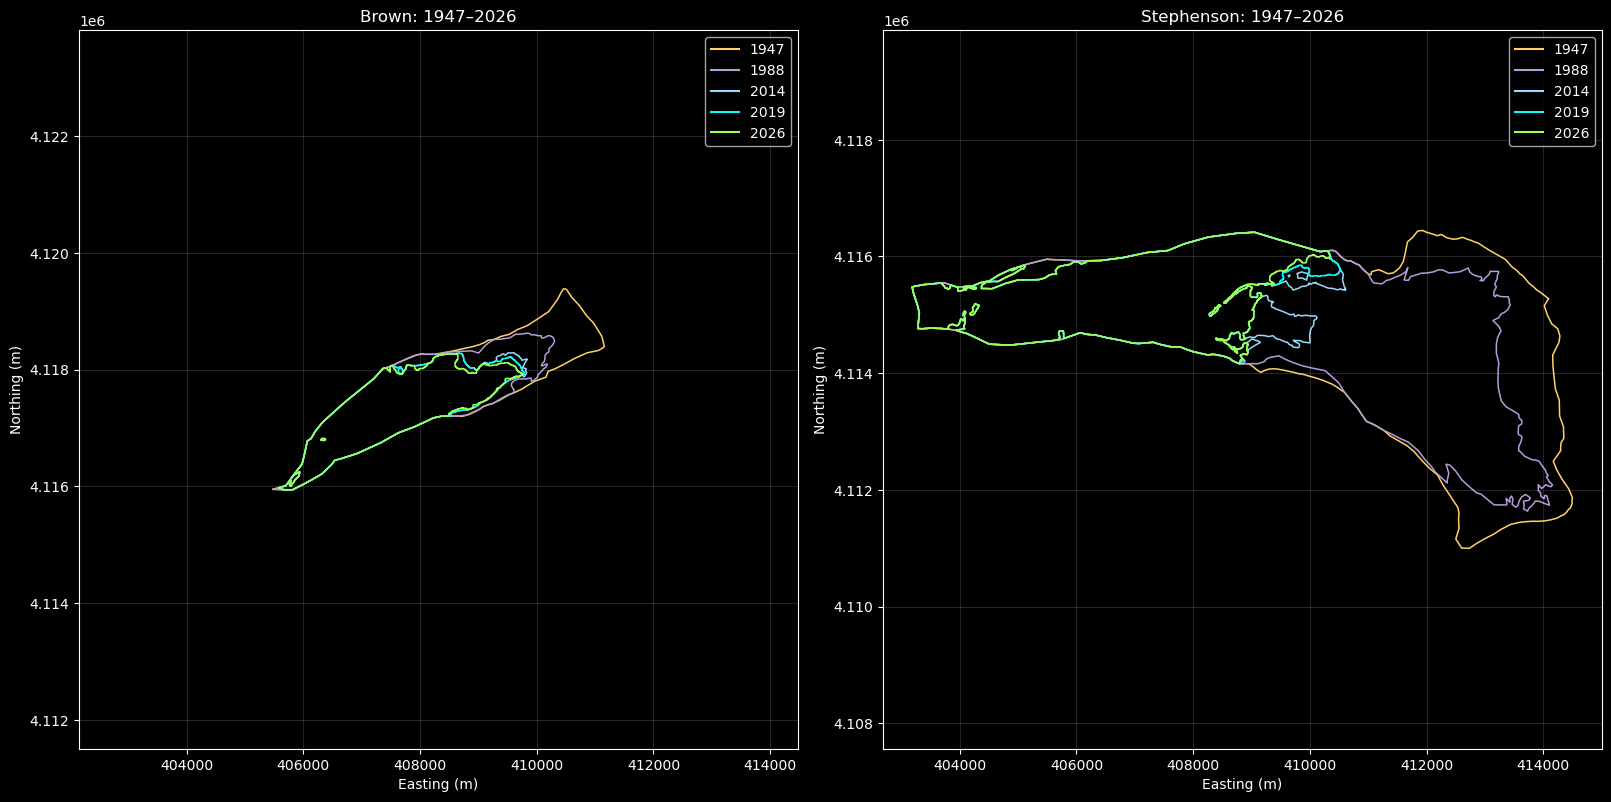

In [9]:
## Compare the five inventories for Brown and Stephenson ##

inventory_colours = {
    1947: "#FFD166", 1988: "#B39DDB", 2014: "#9AD9FF",
    2019: "cyan", 2026: "#9DFF50"}

focus_layers = all_glacier_extents.loc[
    all_glacier_extents["name_1"].astype("string").str.strip()
    .str.casefold().isin(focus_names)].copy()

focus_bounds = {
    name: focus_layers.loc[
        focus_layers["name_1"].str.casefold().eq(name)].total_bounds
    for name in focus_names}

# Give both panels the same map width and height.
plot_span = max(
    max(bounds[2] - bounds[0], bounds[3] - bounds[1])
    for bounds in focus_bounds.values()) + 1_000

legend_items = [
    Line2D([0], [0], color = inventory_colours[year], label = str(year))
    for year in inventory_years]

with plt.style.context("dark_background"):
    comparison_fig, comparison_axes = plt.subplots(
        1, 2, figsize = (16, 9), layout = "constrained")

    for ax, name in zip(comparison_axes, focus_names):
        glacier_layers = focus_layers.loc[
            focus_layers["name_1"].str.casefold().eq(name)]

        for year in inventory_years:
            glacier_layers.loc[glacier_layers["year"].eq(year)].plot(
                ax = ax, facecolor = "none",
                edgecolor = inventory_colours[year], linewidth = 1.1)

        left, bottom, right, top = focus_bounds[name]
        centre_x, centre_y = (left + right) / 2, (bottom + top) / 2

        ax.set(
            title = f"{name.title()}: 1947–2026",
            xlabel = "Easting (m)", ylabel = "Northing (m)",
            xlim = (centre_x - plot_span / 2, centre_x + plot_span / 2),
            ylim = (centre_y - plot_span / 2, centre_y + plot_span / 2))

        ax.set_aspect("equal")
        ax.grid(alpha = 0.15)
        ax.legend(handles = legend_items, loc = "upper right")

    figure_dir = project_dir / "Figures"
    figure_dir.mkdir(parents = True, exist_ok = True)

    comparison_fig.savefig(
        figure_dir / "Brown_Stephenson_extents_1947_2026.png",
        dpi = 200, facecolor = comparison_fig.get_facecolor(),
        bbox_inches = "tight")

    plt.show()

In [10]:
## Export the inventory layers for the interactive map ##

map_data_dir = processed_dir / "interactive_map_data"
map_data_dir.mkdir(parents = True, exist_ok = True)

# Retain the historical date uncertainty in the named glacier layers.
date_notes = historical_matches.loc[
    historical_matches["match_status"].eq("accepted")].groupby(
    ["RGIId", "year"], as_index = False)["pre_year"].any()

date_notes = date_notes.rename(
    columns = {"pre_year": "includes_pre_year"})

map_glaciers = all_glacier_extents.merge(
    date_notes, on = ["RGIId", "year"],
    how = "left", validate = "one_to_one")

map_glaciers["includes_pre_year"] = (
    map_glaciers["includes_pre_year"].eq(True))

map_glaciers.to_crs("EPSG:4326").to_file(
    map_data_dir / "glacier_inventories.geojson",
    driver = "GeoJSON", index = False)

# Island-wide historical inventories include the unmatched ice polygons.
island_records = []

for year in inventory_years:
    if year in (1947, 1988):
        source = historical_matches.loc[
            historical_matches["year"].eq(year)
            & historical_matches["record_class"].eq("ice")].copy()

        unmatched_records = int(
            source["match_status"].eq("unmatched").sum())

        includes_pre_year = bool(source["pre_year"].any())

    elif year == 2014:
        source = glacier_template
        unmatched_records = 0
        includes_pre_year = False

    else:
        source = gpd.read_file(
            final_dir / f"Heard_ice_{year}_final.gpkg",
            layer = f"ice_{year}").to_crs(glacier_template.crs)

        unmatched_records = 0
        includes_pre_year = False

    island_records.append({
        "year": year,
        "unmatched_records": unmatched_records,
        "includes_pre_year": includes_pre_year,
        "geometry": source.geometry.union_all()})

island_inventories = gpd.GeoDataFrame(
    island_records, geometry = "geometry", crs = glacier_template.crs)

island_inventories.to_crs("EPSG:4326").to_file(
    map_data_dir / "island_inventories.geojson",
    driver = "GeoJSON", index = False)

# Preserve statuses for missing history and absent modern mapped extents.
area_history.to_csv(
    map_data_dir / "glacier_area_history.csv", index = False)

The next cell defines the morph and its timing. The 25 m grid applies only to intermediate display frames. Each interval takes two seconds, with a one-second pause at each inventory. Retreat calculations continue to use the original inventories and their actual year gaps.

In [11]:
## Prepare smooth boundary interpolation ##

# Display settings.
animation_pixel_size = 25
transition_seconds = 2.0
pause_seconds = 1.0
animation_fps = 20
transition_frames = round(transition_seconds * animation_fps)


def signed_distance_field(ice_mask, pixel_size):
    # Positive inside ice, negative outside, including internal rock holes.
    return (
        ndi.distance_transform_edt(ice_mask, sampling = pixel_size)
        - ndi.distance_transform_edt(
            ~ice_mask, sampling = pixel_size)).astype("float32")


def prepare_outline_fields(outlines, pixel_size, crs):
    # Include the full historical footprint when setting the animation grid.
    bounds = gpd.GeoSeries(
        list(outlines.values()), crs = crs).total_bounds

    left, bottom, right, top = bounds
    padding = 4 * pixel_size

    left = np.floor(left / pixel_size) * pixel_size - padding
    bottom = np.floor(bottom / pixel_size) * pixel_size - padding
    right = np.ceil(right / pixel_size) * pixel_size + padding
    top = np.ceil(top / pixel_size) * pixel_size + padding

    grid_shape = (
        int(round((top - bottom) / pixel_size)),
        int(round((right - left) / pixel_size)))

    grid_transform = from_origin(left, top, pixel_size, pixel_size)
    fields = {}

    for year, geometry in outlines.items():
        ice_mask = rasterize(
            [(geometry, 1)], out_shape = grid_shape,
            transform = grid_transform,
            fill = 0, dtype = "uint8").astype(bool)

        if not ice_mask.any():
            raise ValueError(
                f"The {year} outline needs a finer animation grid.")

        fields[year] = signed_distance_field(ice_mask, pixel_size)

    return fields, grid_transform


def interpolate_outline(
    start_field, end_field, blend, grid_transform, pixel_size):

    ice_mask = ((1 - blend) * start_field + blend * end_field) > 0

    polygons = [
        shapely_shape(geometry)
        for geometry, value in shapes(
            ice_mask.astype("uint8"),
            mask = ice_mask, transform = grid_transform)
        if value == 1]

    # Reduce raster stair-stepping in the display geometry.
    return union_all(polygons).simplify(
        pixel_size / 2, preserve_topology = True)


# Pause at each inventory and label intermediate frames as interpolation.
animation_plan = [{
    "frame_index": 0,
    "mapped_year": inventory_years[0],
    "from_year": inventory_years[0],
    "to_year": inventory_years[0],
    "blend": 0.0,
    "is_interpolated": False,
    "duration_ms": pause_seconds * 1_000,
    "label": f"{inventory_years[0]} inventory"}]

for start_year, end_year in zip(
    inventory_years[:-1], inventory_years[1:]):

    for progress in np.linspace(
        0, 1, transition_frames + 2)[1:-1]:

        # Ease gently into and out of each transition.
        blend = float(progress * progress * (3 - 2 * progress))

        animation_plan.append({
            "frame_index": len(animation_plan),
            "mapped_year": None,
            "from_year": start_year,
            "to_year": end_year,
            "blend": blend,
            "is_interpolated": True,
            "duration_ms": transition_seconds * 1_000 / transition_frames,
            "label": f"{start_year} → {end_year}: interpolated"})

    animation_plan.append({
        "frame_index": len(animation_plan),
        "mapped_year": end_year,
        "from_year": end_year,
        "to_year": end_year,
        "blend": 0.0,
        "is_interpolated": False,
        "duration_ms": pause_seconds * 1_000,
        "label": f"{end_year} inventory"})

In [12]:
## Save the focus-glacier animation frames ##

# Prepare animation frames for Brown and Stephenson.
animation_records = []

for glacier_id, glacier_layers in focus_layers.groupby("RGIId"):
    glacier_name = glacier_layers["name_1"].iloc[0]
    outlines = glacier_layers.set_index("year").geometry.to_dict()
    missing_years = sorted(set(inventory_years) - set(outlines))

    if missing_years or glacier_layers["needs_review"].any():
        raise ValueError(
            f"Review the inventory history for {glacier_name} "
            "before animating it.")

    fields, grid_transform = prepare_outline_fields(
        outlines, animation_pixel_size, glacier_template.crs)

    for frame in animation_plan:
        if frame["is_interpolated"]:
            geometry = interpolate_outline(
                fields[frame["from_year"]],
                fields[frame["to_year"]],
                frame["blend"], grid_transform, animation_pixel_size)

        else:
            # At inventory dates, use the original polygon and its holes.
            geometry = outlines[frame["mapped_year"]]

        animation_records.append({
            "RGIId": glacier_id,
            "name_1": glacier_name,
            "frame_index": frame["frame_index"],
            "mapped_year": frame["mapped_year"],
            "is_interpolated": frame["is_interpolated"],
            "geometry": geometry})

    print(
        f"{glacier_name}: prepared "
        f"{len(animation_plan)} display frames.")

animation_layers = gpd.GeoDataFrame(
    animation_records, geometry = "geometry", crs = glacier_template.crs)

animation_layers["mapped_year"] = (
    animation_layers["mapped_year"].astype("Int64"))

animation_layers.to_crs("EPSG:4326").to_file(
    map_data_dir / "focus_glacier_animation.geojson",
    driver = "GeoJSON", index = False)

animation_settings = {
    "inventory_years": inventory_years,
    "inventory_colours": inventory_colours,
    "display_grid_metres": animation_pixel_size,
    "timing": "Equal duration per inventory interval; visual pacing only.",
    "historical_date_note": (
        "1947 is a nominal inventory year "
        "and includes Pre year records."),
    "files": {
        "glaciers": "glacier_inventories.geojson",
        "island": "island_inventories.geojson",
        "areas": "glacier_area_history.csv",
        "animation": "focus_glacier_animation.geojson"},
    "frames": animation_plan}

# Carry the frozen outline methodology into the map data package.
outline_metadata_path = final_dir / "outline_metadata.json"

if outline_metadata_path.exists():
    animation_settings["outline_metadata"] = json.loads(
        outline_metadata_path.read_text(encoding = "utf-8"))

settings_path = map_data_dir / "animation_settings.json"

with settings_path.open("w", encoding = "utf-8") as settings_file:
    json.dump(
        animation_settings, settings_file,
        indent = 2, ensure_ascii = False)

print(f"Saved map layers and animation data to: {map_data_dir}")

c:\Users\harry\anaconda3\envs\KGG375_AT3\Lib\site-packages\rasterio\features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


Stephenson: prepared 165 display frames.
Brown: prepared 165 display frames.
Saved map layers and animation data to: c:\Users\harry\OneDrive\Desktop\UNI\UTAS\2026\KGG375_Geospatial_Data_Analytics\AT3\AT3_Group2_2026\Output_Data\processed\interactive_map_data


In [13]:
## Calculate mapped area loss for every glacier ##

# Keep all glaciers and intervals, including missing observations.
comparison_periods = list(zip(inventory_years[:-1], inventory_years[1:]))
comparison_periods.append((inventory_years[0], inventory_years[-1]))

pre_year_records = historical_matches.loc[
    historical_matches["match_status"].eq("accepted")
    & historical_matches["pre_year"],
    ["RGIId", "year"]].drop_duplicates()

pre_year_pairs = set(zip(
    pre_year_records["RGIId"], pre_year_records["year"]))

change_tables = []

for start_year, end_year in comparison_periods:
    starting = area_history.loc[
        area_history["year"].eq(start_year),
        ["RGIId", "name_1", "area_km2", "area_status"]].rename(
        columns = {
            "area_km2": "area_start_km2",
            "area_status": "status_start"})

    ending = area_history.loc[
        area_history["year"].eq(end_year),
        ["RGIId", "area_km2", "area_status"]].rename(
        columns = {
            "area_km2": "area_end_km2",
            "area_status": "status_end"})

    changes = starting.merge(
        ending, on = "RGIId", validate = "one_to_one")

    changes["start_year"] = start_year
    changes["end_year"] = end_year
    changes["period"] = f"{start_year}–{end_year}"
    changes["years_elapsed"] = end_year - start_year

    # Positive values indicate mapped area loss; negative values indicate gain.
    changes["area_loss_km2"] = (
        changes["area_start_km2"] - changes["area_end_km2"])

    # Missing or zero starting areas cannot provide a percentage baseline.
    positive_start = changes["area_start_km2"].where(
        changes["area_start_km2"] > 0)

    changes["area_loss_percent"] = (
        100 * changes["area_loss_km2"] / positive_start)

    changes["annual_loss_km2"] = (
        changes["area_loss_km2"] / changes["years_elapsed"])

    # Linear average relative to the interval's starting area.
    changes["annual_loss_percent"] = (
        changes["area_loss_percent"] / changes["years_elapsed"])

    changes["includes_no_mapped_extent"] = (
        changes["status_start"].eq("no_mapped_extent")
        | changes["status_end"].eq("no_mapped_extent"))

    changes["includes_pre_year"] = [
        (glacier_id, start_year) in pre_year_pairs
        or (glacier_id, end_year) in pre_year_pairs
        for glacier_id in changes["RGIId"]]

    changes["scope"] = (
        changes["name_1"].astype("string").str.strip().str.casefold()
        .isin(focus_names).map({True: "study", False: "context"}))

    change_tables.append(changes)

retreat_statistics = pd.concat(change_tables, ignore_index = True)

full_period = (
    retreat_statistics["start_year"].eq(1947)
    & retreat_statistics["end_year"].eq(2026))

retreat_intervals = retreat_statistics.loc[~full_period].copy()
retreat_totals = retreat_statistics.loc[full_period].copy()

# Save statistics for analysis and the future map popups.
map_data_dir = processed_dir / "interactive_map_data"
map_data_dir.mkdir(parents = True, exist_ok = True)

for directory in (historical_dir, map_data_dir):
    retreat_intervals.to_csv(
        directory / "glacier_retreat_intervals.csv", index = False)

    retreat_totals.to_csv(
        directory / "glacier_retreat_1947_2026.csv", index = False)

# Register the statistics alongside the existing map assets.
settings_path = map_data_dir / "animation_settings.json"

if settings_path.exists():
    map_settings = json.loads(
        settings_path.read_text(encoding = "utf-8"))

    map_settings["files"].update({
        "retreat_intervals": "glacier_retreat_intervals.csv",
        "retreat_totals": "glacier_retreat_1947_2026.csv"})

    settings_path.write_text(
        json.dumps(map_settings, indent = 2, ensure_ascii = False),
        encoding = "utf-8")

focus_statistics = retreat_intervals.loc[
    retreat_intervals["scope"].eq("study"),
    ["name_1", "period", "area_loss_km2", "area_loss_percent",
     "annual_loss_km2", "annual_loss_percent"]]

display(focus_statistics.round(3))

,name_1,period,area_loss_km2,area_loss_percent,annual_loss_km2,annual_loss_percent
4,Stephenson,1947–1988,5.325,20.605,0.130,0.503
22,Brown,1947–1988,1.081,20.171,0.026,0.492
27,Stephenson,1988–2014,11.293,55.033,0.434,2.117
45,Brown,1988–2014,0.873,20.415,0.034,0.785
50,Stephenson,2014–2019,0.851,9.225,0.170,1.845
68,Brown,2014–2019,0.071,2.076,0.014,0.415
73,Stephenson,2019–2026,0.233,2.781,0.033,0.397
91,Brown,2019–2026,0.142,4.270,0.020,0.610


In [14]:
## Set a consistent style for the book figures ##


book_plot_style = {
    "figure.facecolor": "#0B1420",
    "axes.facecolor": "#111E2C",
    "axes.edgecolor": "#587083",
    "axes.labelcolor": "#E8EFF5",
    "text.color": "#E8EFF5",
    "xtick.color": "#BCCBD7",
    "ytick.color": "#BCCBD7",
    "grid.color": "#A8BDCD",
    "grid.alpha": 0.15,
    "grid.linewidth": 0.7,
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "savefig.facecolor": "#0B1420",
    "svg.fonttype": "none"}

focus_colours = {
    "brown": "#FFB36B",
    "stephenson": "#69D5FF"}

figure_dir = project_dir / "Figures"
figure_dir.mkdir(parents = True, exist_ok = True)

# Reuse this style in the inventory notebook's methodology figures.
(processed_dir / "book_figure_style.json").write_text(
    json.dumps(book_plot_style, indent = 2), encoding = "utf-8")

531

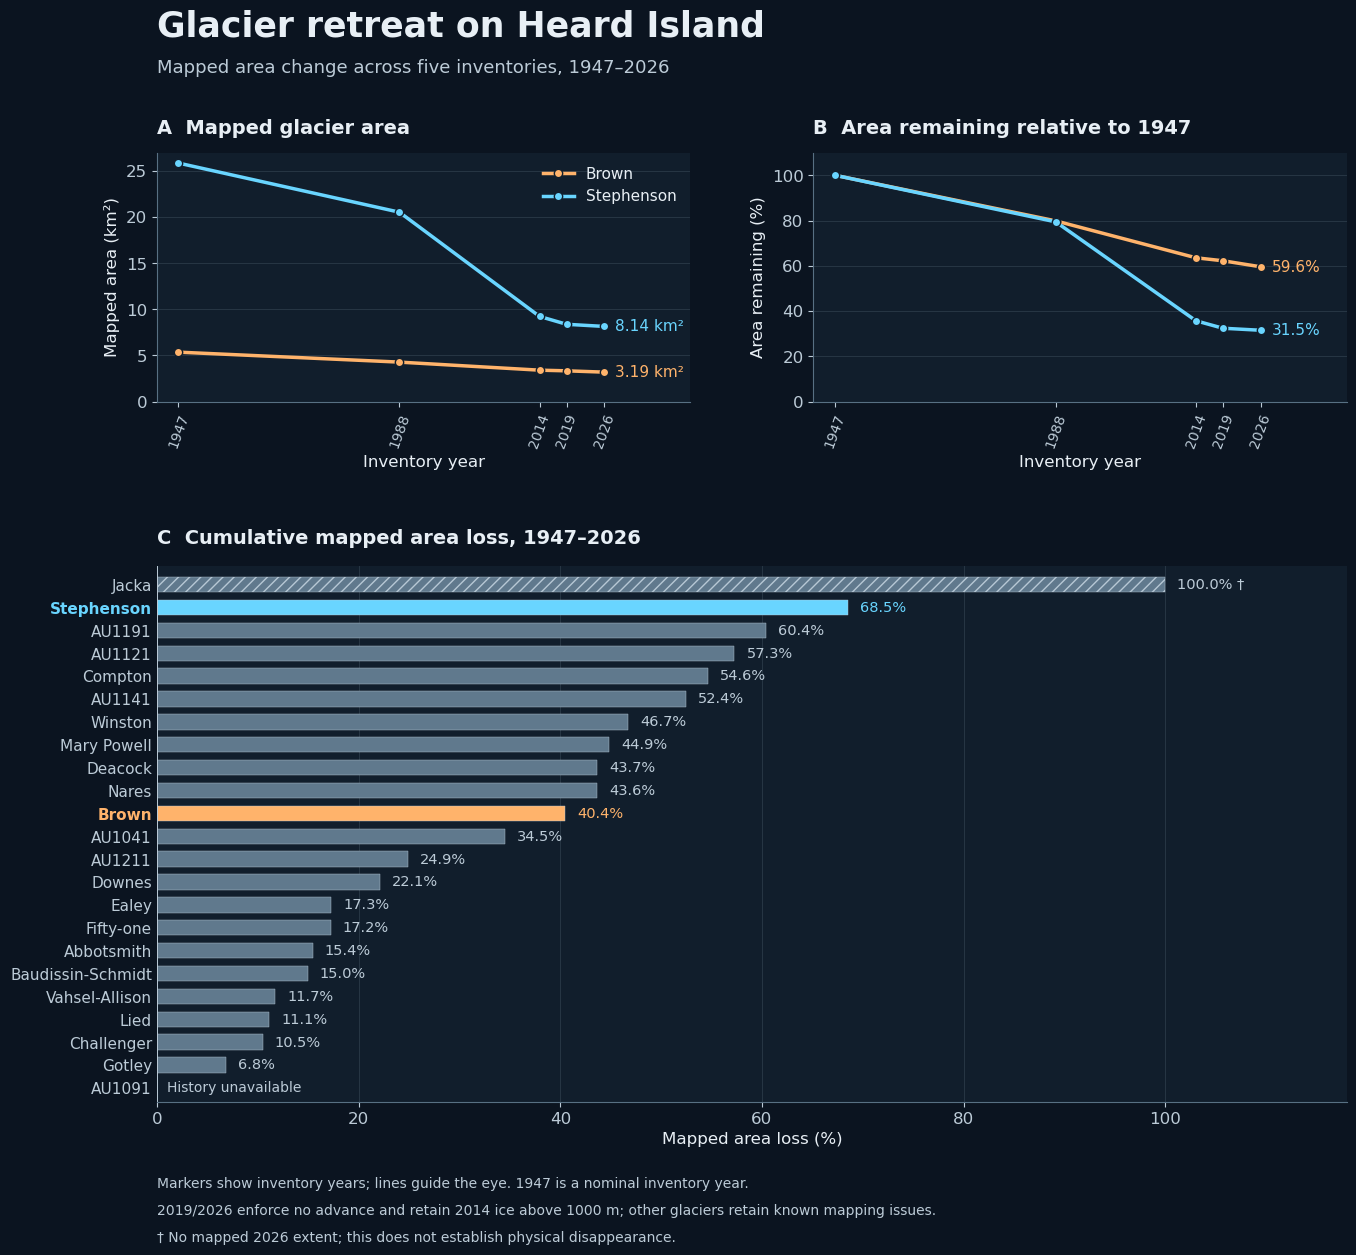

In [15]:
## Figure: Heard Island glacier retreat, 1947–2026 ##

comparison = retreat_totals.sort_values(
    "area_loss_percent", ascending = False,
    na_position = "last").reset_index(drop = True)

with plt.rc_context(book_plot_style):
    retreat_fig = plt.figure(figsize = (14, 13))

    figure_grid = retreat_fig.add_gridspec(
        2, 2, height_ratios = [1, 2.15],
        left = 0.12, right = 0.97, top = 0.86, bottom = 0.13,
        wspace = 0.23, hspace = 0.42)

    area_ax = retreat_fig.add_subplot(figure_grid[0, 0])
    relative_ax = retreat_fig.add_subplot(figure_grid[0, 1])
    comparison_ax = retreat_fig.add_subplot(figure_grid[1, :])

    retreat_fig.text(
        0.12, 0.97, "Glacier retreat on Heard Island",
        fontsize = 25, fontweight = "bold", va = "top")

    retreat_fig.text(
        0.12, 0.932,
        "Mapped area change across five inventories, 1947–2026",
        fontsize = 13, color = "#BCCBD7", va = "top")

    # Show both absolute and proportional changes for the focus glaciers.
    for name in focus_names:
        history = area_history.loc[
            area_history["name_1"].astype("string").str.strip()
            .str.casefold().eq(name)].sort_values("year")

        colour = focus_colours[name]
        baseline = history.loc[
            history["year"].eq(1947), "area_km2"].iloc[0]

        remaining = 100 * history["area_km2"] / baseline

        area_ax.plot(
            history["year"], history["area_km2"], color = colour,
            linewidth = 2.5, marker = "o", markersize = 6,
            markeredgecolor = "#111E2C", label = name.title())

        relative_ax.plot(
            history["year"], remaining, color = colour,
            linewidth = 2.5, marker = "o", markersize = 6,
            markeredgecolor = "#111E2C", label = name.title())

        area_ax.text(
            2028, history["area_km2"].iloc[-1],
            f"{history['area_km2'].iloc[-1]:.2f} km²",
            color = colour, fontsize = 11, va = "center")

        relative_ax.text(
            2028, remaining.iloc[-1], f"{remaining.iloc[-1]:.1f}%",
            color = colour, fontsize = 11, va = "center")

    area_ax.set_title(
        "A  Mapped glacier area", loc = "left", pad = 14)

    relative_ax.set_title(
        "B  Area remaining relative to 1947", loc = "left", pad = 14)

    area_ax.set_ylabel("Mapped area (km²)")
    relative_ax.set_ylabel("Area remaining (%)")
    area_ax.set_ylim(bottom = 0)
    relative_ax.set_ylim(0, 110)
    area_ax.legend(loc = "upper right")

    for ax in (area_ax, relative_ax):
        ax.set_xlim(1943, 2042)
        ax.set_xticks(inventory_years)
        ax.tick_params(
            axis = "x", labelrotation = 70, labelsize = 10)

        ax.set_xlabel("Inventory year")
        ax.grid(axis = "y")
        ax.spines[["top", "right"]].set_visible(False)

    # Keep incomplete histories visible in the island-wide comparison.
    labels = []

    for row_number, row in comparison.iterrows():
        name = (
            str(row["name_1"])
            if pd.notna(row["name_1"]) else row["RGIId"])

        labels.append(name)
        colour = focus_colours.get(
            name.strip().casefold(), "#60798D")

        loss = row["area_loss_percent"]

        if pd.isna(loss):
            comparison_ax.text(
                1, row_number, "History unavailable",
                va = "center", fontsize = 10, color = "#BCCBD7")

            continue

        bars = comparison_ax.barh(
            row_number, loss, height = 0.67,
            color = colour, edgecolor = "#B7C8D5", linewidth = 0.3)

        if row["includes_no_mapped_extent"]:
            bars[0].set_hatch("///")

        qualifier = " †" if row["includes_no_mapped_extent"] else ""
        label_position = loss + 1.2 if loss >= 0 else loss - 1.2
        label_alignment = "left" if loss >= 0 else "right"

        comparison_ax.text(
            label_position, row_number, f"{loss:.1f}%{qualifier}",
            va = "center", ha = label_alignment, fontsize = 10.5,
            color = focus_colours.get(
                name.strip().casefold(), "#BCCBD7"))

    comparison_ax.set_yticks(
        range(len(comparison)), labels = labels)

    comparison_ax.tick_params(
        axis = "y", length = 0, labelsize = 11)

    comparison_ax.set_ylim(len(comparison) - 0.4, -0.8)
    minimum_loss = comparison["area_loss_percent"].min()

    comparison_ax.set_xlim(
        minimum_loss - 14 if minimum_loss < 0 else 0, 118)

    comparison_ax.xaxis.set_major_locator(MaxNLocator(nbins = 6))
    comparison_ax.axvline(0, color = "#BCCBD7", linewidth = 0.7)
    comparison_ax.grid(axis = "x")
    comparison_ax.set_axisbelow(True)

    comparison_ax.spines[
        ["top", "right", "left"]].set_visible(False)

    comparison_ax.set_xlabel("Mapped area loss (%)")
    comparison_ax.set_title(
        "C  Cumulative mapped area loss, 1947–2026",
        loc = "left", pad = 16)

    # Highlight the focus glaciers throughout the figure.
    for tick in comparison_ax.get_yticklabels():
        name = tick.get_text().strip().casefold()

        if name in focus_colours:
            tick.set_color(focus_colours[name])
            tick.set_fontweight("bold")

    retreat_fig.text(
        0.12, 0.064,
        "Markers show inventory years; lines guide the eye. "
        "1947 is a nominal inventory year.",
        fontsize = 10, color = "#BCCBD7")

    retreat_fig.text(
        0.12, 0.043,
        "2019/2026 enforce no advance and retain 2014 ice above 1000 m; "
        "other glaciers retain known mapping issues.",
        fontsize = 10, color = "#BCCBD7")

    retreat_fig.text(
        0.12, 0.022,
        "† No mapped 2026 extent; this does not establish physical disappearance.",
        fontsize = 10, color = "#BCCBD7")

    for extension in ("png", "svg"):
        retreat_fig.savefig(
            figure_dir / f"Heard_glacier_retreat_1947_2026.{extension}",
            dpi = 300, bbox_inches = "tight")

    plt.show()